In [173]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

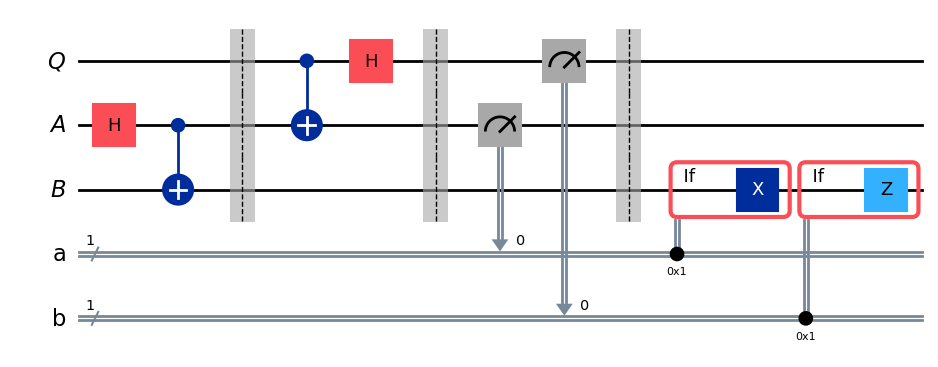

In [174]:
# Teleportation Protocol
qubit = QuantumRegister(1, "Q") # create a quantum register with 1 qubit
ebit0 = QuantumRegister(1, "A") # for Alice
ebit1 = QuantumRegister(1, "B") # for Bob
a = ClassicalRegister(1, "a") # Needed for -Alice-'s measurement result
b = ClassicalRegister(1, "b") # Needed for -Bob-'s measurement result

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b) # Entire Circuit

# Prepare ebit used for teleportation
protocol.h(ebit0) # "hadamard gate" for Alice's qubit
protocol.cx(ebit0, ebit1) # "CNOT" gate to entangle Alice's and Bob's qubits / control = ebit0, target = ebit1
protocol.barrier() 

# Alice's operations
protocol.cx(qubit, ebit0) #"CNOT" gate / control = qubit, target = ebit0
protocol.h(qubit) # "Hadamard" gate to put Alice
protocol.barrier() 

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)): # Check if Alice's measurement result is 1
    protocol.x(ebit1) # True = apply X gate to Bob's qubit
with protocol.if_test((b, 1)): # Check if Bob's measurement result is 1
    protocol.z(ebit1) # True = apply Z gate to Bob's qubit

display(protocol.draw(output="mpl"))

<IPython.core.display.Latex object>

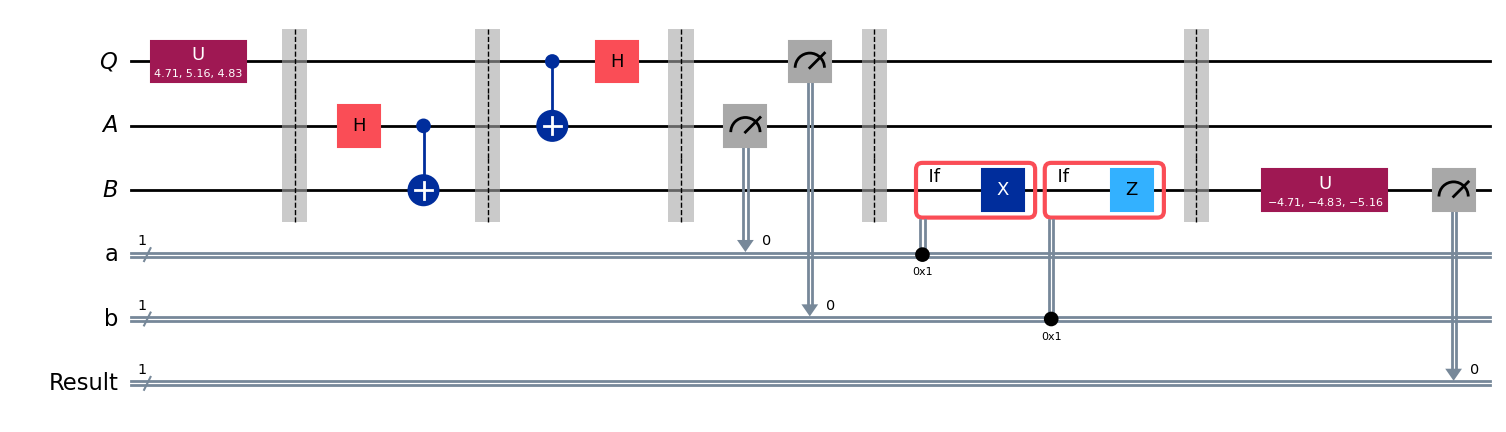

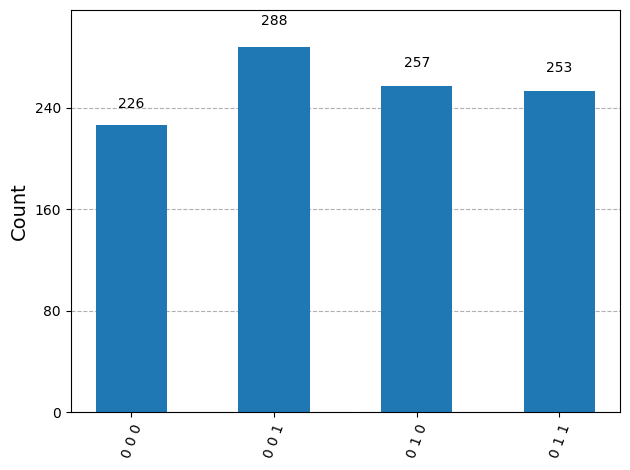

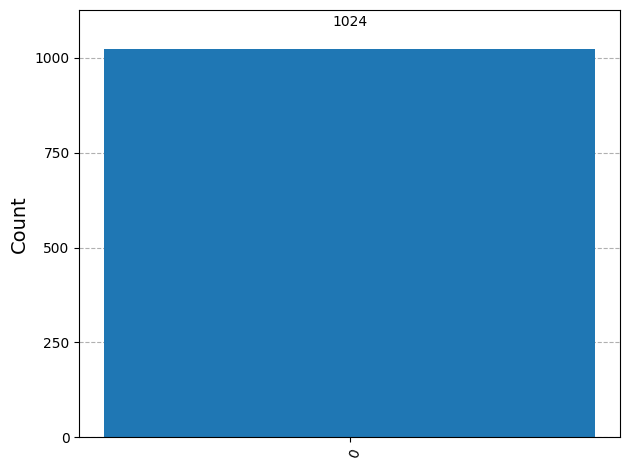

In [175]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Start with the randomly selected gate on Q

test.append(random_gate, qubit) # append UGate to Q
test.barrier()

# Append the entire teleportation protocol from above.

test = test.compose(protocol) # test → protocol
test.barrier()

# Finally, apply the inverse of the random unitary to B and measure.

test.append(random_gate.inverse(), ebit1) # U * U^transpose = I → Why? : Identity means nothing has changed.
result = ClassicalRegister(1, "Result") # Create a classical register to store the measurement result
test.add_register(result) 
test.measure(ebit1, result) 

display(test.draw(output="mpl")) # Used Inverse : first value → - value / Second value → - Third value / Third value → - Second value

result = AerSimulator().run(test).result() #if |011> : result = 0 / b = 1 / a = 1 always read right to left.
statistics = result.get_counts()
display(plot_histogram(statistics))

filtered_statistics = marginal_distribution(statistics, [2]) # the qubits always starts with 0 = result → 100%
display(plot_histogram(filtered_statistics))